# Importing required Library

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading required dataset

In [5]:
orders_items = pd.read_csv('dataset/original_data_source/kolkata_blinkit_order_items.csv')
orders = pd.read_csv('dataset/original_data_source/kolkata_blinkit_orders.csv')
products = pd.read_csv('dataset/original_data_source/kolkata_blinkit_products.csv')

# Dataset Correction and Basic In

## Orders items dataset

In [6]:
orders_items.head(20)

,order_id,product_id,product_name,category,quantity,unit_price,item_total,discount_per_item,supplier_id
0,KOL_ORD_000001,PROD_00008,Onion (1kg),Fruits & Vegetables,3,43.75,131.25,7.29,SUPP_007
1,KOL_ORD_000001,PROD_00033,Fish Fillet (250g),Fish & Meat,3,193.23,579.69,7.23,SUPP_012
2,KOL_ORD_000001,PROD_00103,Red Bull (250ml),Beverages,2,117.73,235.46,10.17,SUPP_021
3,KOL_ORD_000001,PROD_00010,Cauliflower (1pc),Fruits & Vegetables,3,32.65,97.95,9.37,SUPP_005
4,KOL_ORD_000001,PROD_00028,Chicken Curry Cut (1kg),Fish & Meat,3,304.18,912.54,8.22,SUPP_003
5,KOL_ORD_000001,PROD_00080,Haldirams Aloo Bhujia (200g),Snacks & Biscuits,1,97.25,97.25,9.18,SUPP_033
6,KOL_ORD_000001,PROD_00149,Rosogolla (500g),Sweet & Confectionery,3,114.53,343.59,7.70,SUPP_049
7,KOL_ORD_000001,PROD_00057,Whole Wheat Atta (1kg),Rice & Atta,3,49.08,147.24,9.27,SUPP_019
8,KOL_ORD_000002,PROD_00030,Eggs (6 pcs),Fish & Meat,1,73.34,73.34,1.93,SUPP_036
9,KOL_ORD_000002,PROD_00077,Fennel Seeds (100g),Spices & Masalas,3,58.35,175.05,2.50,SUPP_009


In [7]:
orders_items.isnull().sum()

order_id             0
product_id           0
product_name         0
category             0
quantity             0
unit_price           0
item_total           0
discount_per_item    0
supplier_id          0
dtype: int64

In [8]:
orders_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 331780 entries, 0 to 331779
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_id           331780 non-null  str    
 1   product_id         331780 non-null  str    
 2   product_name       331780 non-null  str    
 3   category           331780 non-null  str    
 4   quantity           331780 non-null  int64  
 5   unit_price         331780 non-null  float64
 6   item_total         331780 non-null  float64
 7   discount_per_item  331780 non-null  float64
 8   supplier_id        331780 non-null  str    
dtypes: float64(3), int64(1), str(5)
memory usage: 22.8 MB


In [9]:
supplier_product_count = (
    orders_items
    .groupby('supplier_id')['product_id']
    .nunique()
    .reset_index(name='# products')
)
print(supplier_product_count)

   supplier_id  # products
0     SUPP_001           2
1     SUPP_002           2
2     SUPP_003           1
3     SUPP_004           4
4     SUPP_005           5
5     SUPP_006           2
6     SUPP_007           5
7     SUPP_008           3
8     SUPP_009           8
9     SUPP_010           5
10    SUPP_011           1
11    SUPP_012           2
12    SUPP_013           2
13    SUPP_014           2
14    SUPP_015           1
15    SUPP_016           7
16    SUPP_017           4
17    SUPP_018           4
18    SUPP_019           1
19    SUPP_020           4
20    SUPP_021           4
21    SUPP_022           3
22    SUPP_023           4
23    SUPP_024           3
24    SUPP_025           1
25    SUPP_026           4
26    SUPP_027           5
27    SUPP_028           3
28    SUPP_029           4
29    SUPP_030           3
30    SUPP_031           5
31    SUPP_032           5
32    SUPP_033           2
33    SUPP_035           3
34    SUPP_036           6
35    SUPP_037           2
3

In [10]:
orders_items.to_csv('dataset/orders_items.csv',index=False)

## Orders dataset

In [11]:
orders

,order_id,order_date,order_time,customer_id,store_id,campaign_id,total_amount,delivery_fee,discount_amount,net_revenue,payment_method,delivery_duration_minutes,delivery_rating,order_status,is_festival_day,bengali_household
0,KOL_ORD_000001,01-01-24,8:29:51 AM,KOL_CUST_006904,BLK_KOL_009,NaN,2544.97,0,67.91,2477.06,UPI,40,4.3,Delivered,True,True
1,KOL_ORD_000002,01-01-24,8:00:06 AM,KOL_CUST_006827,BLK_KOL_047,NaN,248.39,0,4.20,244.19,UPI,34,4.1,Delivered,True,True
2,KOL_ORD_000003,01-01-24,8:18:50 AM,KOL_CUST_003173,BLK_KOL_025,NaN,202.71,30,0.08,232.63,Cash on Delivery,41,3.9,Delivered,True,True
3,KOL_ORD_000004,01-01-24,8:57:41 AM,KOL_CUST_003899,BLK_KOL_008,NaN,1322.24,30,52.43,1299.81,UPI,43,3.9,Delivered,True,True
4,KOL_ORD_000005,01-01-24,8:34:30 AM,KOL_CUST_000759,BLK_KOL_038,NaN,1969.24,30,67.39,1931.85,Cash on Delivery,31,4.9,Delivered,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73586,KOL_ORD_073587,31-12-24,9:28:22 PM,KOL_CUST_006018,BLK_KOL_040,KOL_WINTER_2024,106.36,0,15.10,91.26,UPI,55,4.4,Delivered,False,True
73587,KOL_ORD_073588,31-12-24,9:23:06 PM,KOL_CUST_007185,BLK_KOL_049,KOL_WINTER_2024,1536.40,0,196.80,1339.60,UPI,46,4.5,Delivered,False,True
73588,KOL_ORD_073589,31-12-24,9:57:43 PM,KOL_CUST_007379,BLK_KOL_039,KOL_WINTER_2024,584.50,30,58.96,555.54,Debit Card,52,4.8,Delivered,False,True
73589,KOL_ORD_073590,31-12-24,9:11:11 PM,KOL_CUST_003676,BLK_KOL_008,KOL_WINTER_2024,1724.87,0,205.34,1519.53,UPI,53,4.4,Delivered,False,True


In [12]:
print(type(orders['order_date'][0]))
print(type(orders['order_date'][0]))

<class 'str'>
<class 'str'>


In [13]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_time'] = pd.to_datetime(orders['order_time']).dt.time

orders

C:\Users\dpaul\AppData\Local\Temp\ipykernel_16532\892821715.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders['order_date'] = pd.to_datetime(orders['order_date'])
C:\Users\dpaul\AppData\Local\Temp\ipykernel_16532\892821715.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders['order_time'] = pd.to_datetime(orders['order_time']).dt.time


,order_id,order_date,order_time,customer_id,store_id,campaign_id,total_amount,delivery_fee,discount_amount,net_revenue,payment_method,delivery_duration_minutes,delivery_rating,order_status,is_festival_day,bengali_household
0,KOL_ORD_000001,2024-01-01,08:29:51,KOL_CUST_006904,BLK_KOL_009,NaN,2544.97,0,67.91,2477.06,UPI,40,4.3,Delivered,True,True
1,KOL_ORD_000002,2024-01-01,08:00:06,KOL_CUST_006827,BLK_KOL_047,NaN,248.39,0,4.20,244.19,UPI,34,4.1,Delivered,True,True
2,KOL_ORD_000003,2024-01-01,08:18:50,KOL_CUST_003173,BLK_KOL_025,NaN,202.71,30,0.08,232.63,Cash on Delivery,41,3.9,Delivered,True,True
3,KOL_ORD_000004,2024-01-01,08:57:41,KOL_CUST_003899,BLK_KOL_008,NaN,1322.24,30,52.43,1299.81,UPI,43,3.9,Delivered,True,True
4,KOL_ORD_000005,2024-01-01,08:34:30,KOL_CUST_000759,BLK_KOL_038,NaN,1969.24,30,67.39,1931.85,Cash on Delivery,31,4.9,Delivered,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73586,KOL_ORD_073587,2024-12-31,21:28:22,KOL_CUST_006018,BLK_KOL_040,KOL_WINTER_2024,106.36,0,15.10,91.26,UPI,55,4.4,Delivered,False,True
73587,KOL_ORD_073588,2024-12-31,21:23:06,KOL_CUST_007185,BLK_KOL_049,KOL_WINTER_2024,1536.40,0,196.80,1339.60,UPI,46,4.5,Delivered,False,True
73588,KOL_ORD_073589,2024-12-31,21:57:43,KOL_CUST_007379,BLK_KOL_039,KOL_WINTER_2024,584.50,30,58.96,555.54,Debit Card,52,4.8,Delivered,False,True
73589,KOL_ORD_073590,2024-12-31,21:11:11,KOL_CUST_003676,BLK_KOL_008,KOL_WINTER_2024,1724.87,0,205.34,1519.53,UPI,53,4.4,Delivered,False,True


In [14]:
print(orders['order_date'])

0       2024-01-01
1       2024-01-01
2       2024-01-01
3       2024-01-01
4       2024-01-01
           ...    
73586   2024-12-31
73587   2024-12-31
73588   2024-12-31
73589   2024-12-31
73590   2024-12-31
Name: order_date, Length: 73591, dtype: datetime64[us]


In [15]:
store_customer_count = (
    orders
    .groupby('store_id')['order_id']
    .nunique()
    .reset_index(name='# orders')
)
store_customer_count

,store_id,# orders
0,BLK_KOL_001,1420
1,BLK_KOL_002,1426
2,BLK_KOL_003,1388
3,BLK_KOL_004,1353
4,BLK_KOL_005,1474
5,BLK_KOL_006,1374
6,BLK_KOL_007,1323
7,BLK_KOL_008,1367
8,BLK_KOL_009,1342
9,BLK_KOL_010,1384


In [16]:
payment_method_customer_count = (
    orders
    .groupby('payment_method')['order_id']
    .nunique()
    .reset_index(name='# orders')
)
payment_method_customer_count.sort_values(by=['# orders'], ascending=False)

,payment_method,# orders
4,UPI,40346
0,Cash on Delivery,10913
1,Credit Card,7527
2,Debit Card,7483
3,Net Banking,3661
5,Wallet,3661


In [17]:
orders.to_csv('dataset/orders.csv',index=False)

## Products dataset

In [18]:
products.head(20)

,product_id,product_name,category,subcategory,unit_price,cost_price,supplier_id,is_active
0,PROD_00001,Mango (1kg),Fruits & Vegetables,General,192.99,137.78,SUPP_038,True
1,PROD_00002,Banana (1kg),Fruits & Vegetables,General,51.89,37.56,SUPP_027,True
2,PROD_00003,Apple (1kg),Fruits & Vegetables,General,215.74,153.83,SUPP_021,True
3,PROD_00004,Orange (1kg),Fruits & Vegetables,General,117.39,75.23,SUPP_046,True
4,PROD_00005,Guava (1kg),Fruits & Vegetables,General,72.57,47.40,SUPP_009,True
5,PROD_00006,Tomato (1kg),Fruits & Vegetables,General,63.58,41.97,SUPP_021,True
6,PROD_00007,Potato (1kg),Fruits & Vegetables,General,38.94,30.65,SUPP_001,True
7,PROD_00008,Onion (1kg),Fruits & Vegetables,General,43.75,34.99,SUPP_007,True
8,PROD_00009,Brinjal (1kg),Fruits & Vegetables,General,41.47,26.65,SUPP_017,True
9,PROD_00010,Cauliflower (1pc),Fruits & Vegetables,General,32.65,21.87,SUPP_005,True


In [19]:
products.isnull().sum()

product_id      0
product_name    0
category        0
subcategory     0
unit_price      0
cost_price      0
supplier_id     0
is_active       0
dtype: int64

In [20]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    166 non-null    str    
 1   product_name  166 non-null    str    
 2   category      166 non-null    str    
 3   subcategory   166 non-null    str    
 4   unit_price    166 non-null    float64
 5   cost_price    166 non-null    float64
 6   supplier_id   166 non-null    str    
 7   is_active     166 non-null    bool   
dtypes: bool(1), float64(2), str(5)
memory usage: 9.4 KB


In [21]:
category_product_count = (
    products
    .groupby('category')['product_id']
    .nunique()
    .reset_index(name='# products')
)
category_product_count

,category,# products
0,Beverages,20
1,Dairy & Eggs,15
2,Fish & Meat,14
3,Fruits & Vegetables,20
4,Home Care,15
5,Personal Care,19
6,Rice & Atta,14
7,Snacks & Biscuits,16
8,Spices & Masalas,15
9,Sweet & Confectionery,18


In [22]:
print(products['unit_price'].dtype)
print(products['product_id'].dtype)
print(products['is_active'].dtype)

float64
str
bool


In [23]:
products.to_csv('dataset/products.csv',index=False)

# Basic Visualization

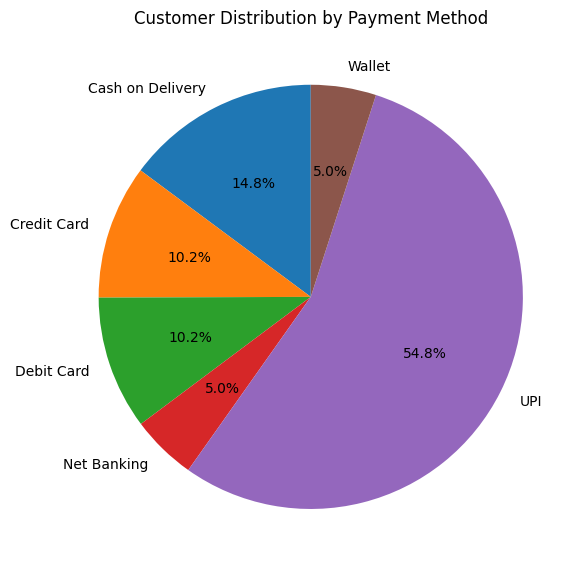

In [24]:
plt.figure(figsize=(6, 6))
plt.pie(
    payment_method_customer_count['# orders'],
    labels=payment_method_customer_count['payment_method'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Customer Distribution by Payment Method')
plt.tight_layout()
plt.show()

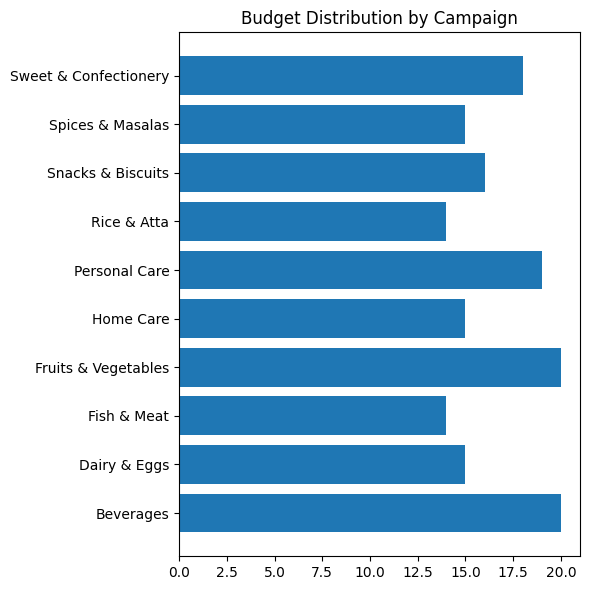

In [25]:
plt.figure(figsize=(6, 6))
plt.barh(
    category_product_count['category'],
    category_product_count['# products'],
)
plt.title('Budget Distribution by Campaign')
plt.tight_layout()
plt.show()